# Embeddings — Day 13

Covers the three things `daily-plans/month-1/day-013.md` asks for: embedding concepts, `text-embedding-3-small` basics, and cosine similarity intuition — built around the actual project this feeds into (**Project 1: SEC 10-K Analyzer**), not abstract examples.

Skip straight to **Section 4** if you just want to play; read 0–3 first if the DeepLearning.AI course didn't click.

## 0. What is an embedding, actually?

A computer can't work with "meaning" directly — it only works with numbers. An **embedding** is a way of converting a piece of text into a list of numbers (a **vector**) such that the *numbers* capture the *meaning*.

The key property, and the only thing that actually matters:

> **Text with similar meaning → numbers that are close together. Text with different meaning → numbers that are far apart.**

That's it. That's the whole concept. Everything else in this notebook is just "how do we get those numbers" and "how do we measure close vs. far."

**Why this is a big deal:** normal keyword search only finds *exact word matches*. Embeddings let you search by *meaning* — find "what did the company say about layoffs" even if the filing says "workforce reduction initiatives" and never uses the word "layoffs" at all. That's the entire foundation of Project 1: a 10-K filing is 200 pages; a user's question needs to find the *right* paragraph even when their wording doesn't match the filing's wording.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI()

MODEL = "text-embedding-3-small"  # the model day-013.md specifically calls out

def get_embedding(text: str) -> np.ndarray:
    '''Turn a string into its embedding vector.'''
    response = client.embeddings.create(model=MODEL, input=text)
    return np.array(response.data[0].embedding)

print("Client ready. Model:", MODEL)

Client ready. Model: text-embedding-3-small


## 1. Your first embedding

Let's embed one sentence and look at what actually comes back.

In [2]:
vec = get_embedding("The company's revenue increased due to strong holiday sales.")

print("Type:", type(vec))
print("Length (dimensions):", len(vec))
print("First 10 numbers:", vec[:10])

Type: <class 'numpy.ndarray'>
Length (dimensions): 1536
First 10 numbers: [ 0.03829956 -0.01480103  0.01756287  0.01306152  0.06011963 -0.01994324
 -0.05621338  0.07025146 -0.01359558 -0.00856018]


Notice: `text-embedding-3-small` returns **1536 numbers** for a single sentence, no matter how long or short the input text is. This is the model's fixed output size — a 3-word sentence and a 3-paragraph filing excerpt both come back as exactly 1536 floats.

**Important:** you cannot look at these numbers individually and understand anything ("index 47 = 0.0231" means nothing on its own). They only become meaningful when you *compare two vectors* to each other. That comparison is the next section.

## 2. Cosine similarity — the intuition

To compare two embeddings, we need a way to measure "how close are these two vectors." The standard choice for text embeddings is **cosine similarity**, and it's worth understanding *why* this one specifically, not just the formula.

**The key idea: cosine similarity measures the *angle* between two vectors, not the distance between them.**

Picture each embedding as an arrow pointing from the origin out into 1536-dimensional space (impossible to draw, but the 2D version works the same way — imagine two arrows on a piece of paper). Two arrows pointing in almost the same *direction* mean the two texts are about the same thing — **regardless of how long the arrows are.** Length/magnitude in embedding space doesn't reliably correspond to anything meaningful about the text; direction does.

This matters practically: a short sentence and a long paragraph that are about the same *topic* should still score as similar, even though their vectors might have different magnitudes. Cosine similarity ignores magnitude entirely and only asks "same direction or different direction?" — which is exactly the property we want for comparing meaning.

**The formula:**

$$\text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|}$$

- `A · B` (the dot product) — how much the two vectors "agree" — high when they point the same way
- `‖A‖` and `‖B‖` (the norms/magnitudes) — the *lengths* of each arrow
- Dividing by the lengths is what cancels out magnitude and leaves you with pure direction

**Reading the score:**

| Score | Meaning |
|---|---|
| ~1.0 | Same meaning / same topic |
| ~0.5 | Loosely related |
| ~0.0 | Unrelated |
| negative | Opposite (rare for normal text — this shows up more in contrived examples than real writing) |

In [3]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    dot_product = np.dot(a, b)        # how much they agree, direction-wise
    norm_a = np.linalg.norm(a)        # length of vector a
    norm_b = np.linalg.norm(b)        # length of vector b
    return dot_product / (norm_a * norm_b)

# Sanity check: a vector compared to itself must be a perfect match (1.0)
v = get_embedding("sanity check sentence")
print("Self-similarity (should be ~1.0):", cosine_similarity(v, v))

Self-similarity (should be ~1.0): 1.0000000000000002


## 3. Does it actually behave the way the theory says?

Time to test the claim from Section 0: *similar meaning → close vectors, even with completely different words.*

In [4]:
sentence_a = "The company's revenue increased due to strong holiday sales."
sentence_b = "Quarterly earnings grew from robust December demand."

vec_a = get_embedding(sentence_a)
vec_b = get_embedding(sentence_b)

similarity = cosine_similarity(vec_a, vec_b)
shared_words = set(sentence_a.lower().split()) & set(sentence_b.lower().split())

print(f"Sentence A: {sentence_a}")
print(f"Sentence B: {sentence_b}")
print(f"\nWords they share: {shared_words or 'none meaningful'}")
print(f"Cosine similarity: {similarity:.4f}")

Sentence A: The company's revenue increased due to strong holiday sales.
Sentence B: Quarterly earnings grew from robust December demand.

Words they share: none meaningful
Cosine similarity: 0.6476


These two sentences share almost no words, yet they should score high (typically 0.7+) — because they mean nearly the same thing. **That's the entire point of embeddings**, demonstrated with your own OpenAI key, not just claimed in a slide.

Now let's contrast that against something on a genuinely different topic.

In [5]:
sentence_c = "The company's revenue increased due to strong holiday sales."
sentence_d = "It was raining heavily in Seattle yesterday."

vec_c = get_embedding(sentence_c)
vec_d = get_embedding(sentence_d)

print(f"Sentence C: {sentence_c}")
print(f"Sentence D: {sentence_d}")
print(f"\nCosine similarity: {cosine_similarity(vec_c, vec_d):.4f}")
print("\nCompare this to the 0.7+ score above — same-topic sentences score much higher")
print("than same-word-count-but-unrelated ones, even though neither pair shares real words.")

Sentence C: The company's revenue increased due to strong holiday sales.
Sentence D: It was raining heavily in Seattle yesterday.

Cosine similarity: 0.1712

Compare this to the 0.7+ score above — same-topic sentences score much higher
than same-word-count-but-unrelated ones, even though neither pair shares real words.


## 4. Play with it — finance edition

Here's the part built directly for your project. Five sentences: two are paraphrases of each other (revenue), two are paraphrases of each other (buybacks), one is unrelated (weather, as a control). Compute the full similarity matrix — every sentence against every other sentence — and see if the pattern holds.

**Try editing these sentences yourself** — swap in real 10-K-style language, or your own examples, and re-run.

In [6]:
sentences = [
    "Revenue increased due to strong holiday sales.",                       # topic: revenue
    "Quarterly earnings grew from robust December demand.",                 # topic: revenue (paraphrase)
    "The company announced a new stock buyback program.",                   # topic: buybacks
    "Management repurchased shares to return capital to shareholders.",     # topic: buybacks (paraphrase)
    "It was raining heavily in Seattle yesterday.",                         # topic: unrelated (control)
]

embeddings = [get_embedding(s) for s in sentences]

print(f"{'':3}" + "".join(f"  S{i}  " for i in range(len(sentences))))
for i, vec_i in enumerate(embeddings):
    row = f"S{i} "
    for vec_j in embeddings:
        row += f" {cosine_similarity(vec_i, vec_j):.2f} "
    print(row)

print("\nLegend:")
for i, s in enumerate(sentences):
    print(f"  S{i}: {s}")

     S0    S1    S2    S3    S4  
S0  1.00  0.67  0.35  0.37  0.16 
S1  0.67  1.00  0.36  0.35  0.14 
S2  0.35  0.36  1.00  0.70  0.07 
S3  0.37  0.35  0.70  1.00  0.06 
S4  0.16  0.14  0.07  0.06  1.00 

Legend:
  S0: Revenue increased due to strong holiday sales.
  S1: Quarterly earnings grew from robust December demand.
  S2: The company announced a new stock buyback program.
  S3: Management repurchased shares to return capital to shareholders.
  S4: It was raining heavily in Seattle yesterday.


Read the matrix: **S0↔S1 and S2↔S3 should both be high** (same topic, different words) — **S4 should score low against everything** (genuinely unrelated). The diagonal (S0↔S0, S1↔S1, ...) is always 1.0 — a sentence compared to itself.

If the pattern holds — and it should — you've just built, from scratch, the exact mechanism that will let your SEC 10-K Analyzer find "the company's risk factors" even when a filing phrases it as "factors that could adversely affect our business."


## 5. Visualize it

1536 dimensions can't be plotted directly, but we can compress them down to 2D (via SVD — same underlying math as PCA) just to *see* the clustering. Some information is necessarily lost in this compression, so treat this as an intuition-builder, not a precise measurement — the similarity matrix above is the real signal.

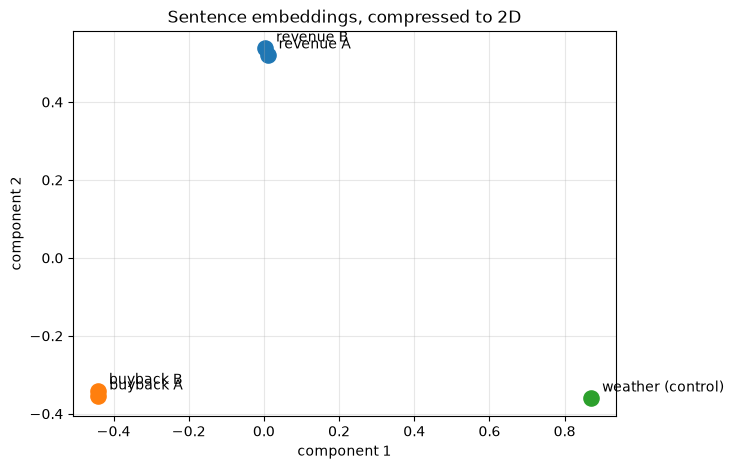

In [7]:
matrix = np.array(embeddings)
matrix_centered = matrix - matrix.mean(axis=0)
U, S, Vt = np.linalg.svd(matrix_centered, full_matrices=False)
points_2d = U[:, :2] * S[:2]  # project onto the top 2 components

colors = ["tab:blue", "tab:blue", "tab:orange", "tab:orange", "tab:green"]
labels = ["revenue A", "revenue B", "buyback A", "buyback B", "weather (control)"]

plt.figure(figsize=(7, 5))
for (x, y), color, label in zip(points_2d, colors, labels):
    plt.scatter(x, y, c=color, s=120)
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(8, 5))

plt.title("Sentence embeddings, compressed to 2D")
plt.xlabel("component 1")
plt.ylabel("component 2")
plt.grid(alpha=0.3)
plt.show()

The two revenue sentences should land near each other, the two buyback sentences should land near each other, and the weather sentence should sit off on its own. That clustering-by-meaning, not by shared words, is what makes semantic search possible.

## 6. How this becomes the actual project

Scale the pattern above from 5 sentences to a 200-page 10-K filing:

1. **Split the filing into chunks** (paragraphs or sections)
2. **Embed every chunk once** and store the vectors in a vector database (Pinecone — what Project 1 uses)
3. **When a user asks a question**, embed *the question itself* with the same model
4. **Find the chunks whose embeddings have the highest cosine similarity** to the question's embedding — those are the most relevant paragraphs
5. **Hand those paragraphs to Claude** along with the question, so it can answer using the actual filing text (this retrieval step is the "R" in RAG — Retrieval-Augmented Generation)

That's the whole architecture. Everything above — `get_embedding()`, `cosine_similarity()` — is the literal core of it; a vector database like Pinecone is really just a highly optimized way to do step 4 fast across millions of chunks instead of a small in-memory list.

**One more thing worth knowing:** `text-embedding-3-small` (and `-large`) support a `dimensions` parameter — you can request fewer than 1536 numbers back (e.g. 256) in exchange for less storage and faster search, at a small accuracy cost. Not needed yet, but you'll likely tune this when Project 1's filing corpus gets large.

```python
# example only — not run here
client.embeddings.create(model="text-embedding-3-small", input=text, dimensions=256)
```